#Importação de Bibliotecas

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Extração de Dados

In [3]:
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/main/TelecomX_Data.json"

response = requests.get(url)
response.raise_for_status()

data_json = response.json()

df = pd.json_normalize(data_json, sep='.')

print("Dimensão do dataset:", df.shape)
df.head()

Dimensão do dataset: (7267, 21)


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# Dicionário de Dados

In [4]:
url_dict = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/main/TelecomX_dicionario.md"

response_dict = requests.get(url_dict)
response_dict.raise_for_status()

dict_md = response_dict.text

print(dict_md[:500])

#### Dicionário de dados

* `customerID`: número de identificação único de cada cliente
* `Churn`: se o cliente deixou ou não a empresa 
* `gender`: gênero (masculino e feminino) 
* `SeniorCitizen`: informação sobre um cliente ter ou não idade igual ou maior que 65 anos 
* `Partner`:  se o cliente possui ou não um parceiro ou parceira
* `Dependents`: se o cliente possui ou não dependentes
* `tenure`:  meses de contrato do cliente
* `PhoneService`: assinatura de serviço telefônico 
* `MultipleLin


# Extração Inicial

In [5]:
print("Tipos de dados:\n")
print(df.dtypes)

print("\nValores ausentes por coluna:\n")
print(df.isnull().sum())

print("\nValores vazios:\n")
print((df == '').sum())

print("\nLinhas duplicadas:", df.duplicated().sum())

Tipos de dados:

customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object
dtype: object

Valores ausentes por coluna:

customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
custom

# Limpeza e Tratamento de Dados

In [6]:
# Remover registros com churn vazio
df = df[df['Churn'].notnull()]
df = df[df['Churn'] != '']

# Remover duplicatas
df = df.drop_duplicates()

# Colunas categóricas
colunas_categoricas = [
    'Churn',
    'customer.gender',
    'customer.Partner',
    'customer.Dependents',
    'phone.PhoneService',
    'phone.MultipleLines',
    'internet.InternetService',
    'internet.OnlineSecurity',
    'internet.OnlineBackup',
    'internet.DeviceProtection',
    'internet.TechSupport',
    'internet.StreamingTV',
    'internet.StreamingMovies',
    'account.Contract',
    'account.PaperlessBilling',
    'account.PaymentMethod'
]

# Padronização de texto
for col in colunas_categoricas:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

# Conversão de valores numéricos
df['account.Charges.Monthly'] = pd.to_numeric(df['account.Charges.Monthly'], errors='coerce')
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Preencher valores nulos
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)

# Converter para inteiro
df['customer.tenure'] = df['customer.tenure'].astype(int)
df['customer.SeniorCitizen'] = df['customer.SeniorCitizen'].astype(int)

print("Dados tratados com sucesso.")
df.head()

Dados tratados com sucesso.


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,Dsl,...,Yes,No,Yes,Yes,No,One Year,Yes,Mailed Check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,Dsl,...,No,No,No,No,Yes,Month-To-Month,No,Mailed Check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber Optic,...,No,Yes,No,No,No,Month-To-Month,Yes,Electronic Check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber Optic,...,Yes,Yes,No,Yes,Yes,Month-To-Month,Yes,Electronic Check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber Optic,...,No,No,Yes,Yes,No,Month-To-Month,Yes,Mailed Check,83.9,267.40


# Criação de Nova Variável

In [7]:
# Valor diário estimado
df['Contas_Diarias'] = df['account.Charges.Monthly'] / 30

df[['account.Charges.Monthly','Contas_Diarias']].head()

,account.Charges.Monthly,Contas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


# Estatísticas Descritivas

In [8]:
print("Estatísticas descritivas:")
display(df.describe().T)

print("\nMedianas:")
print(df.median(numeric_only=True))

print("\nClientes por status de churn:")
print(df['Churn'].value_counts())

print("\nMédia de gasto mensal por tipo de contrato:")
print(df.groupby('account.Contract')['account.Charges.Monthly'].mean())

print("\nDesvio padrão do valor diário:")
print(df['Contas_Diarias'].std())

Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
customer.SeniorCitizen,7043.0,0.162147,0.368612,0.000000,0.000000,0.000,0.000,1.000000
customer.tenure,7043.0,32.371149,24.559481,0.000000,9.000000,29.000,55.000,72.000000
account.Charges.Monthly,7043.0,64.761692,30.090047,18.250000,35.500000,70.350,89.850,118.750000
account.Charges.Total,7043.0,2279.734304,2266.794470,0.000000,398.550000,1394.550,3786.600,8684.800000
Contas_Diarias,7043.0,2.158723,1.003002,0.608333,1.183333,2.345,2.995,3.958333



Medianas:
customer.SeniorCitizen        0.000
customer.tenure              29.000
account.Charges.Monthly      70.350
account.Charges.Total      1394.550
Contas_Diarias                2.345
dtype: float64

Clientes por status de churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Média de gasto mensal por tipo de contrato:
account.Contract
Month-To-Month    66.398490
One Year          65.048608
Two Year          60.770413
Name: account.Charges.Monthly, dtype: float64

Desvio padrão do valor diário:
1.0030015699226154


# Análise Exploratória

 **Distribuição de Churn**

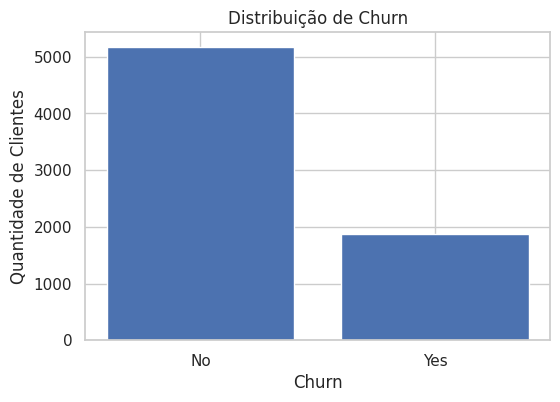

In [9]:
counts = df['Churn'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title('Distribuição de Churn')
plt.xlabel('Churn')
plt.ylabel('Quantidade de Clientes')

plt.show()

**Churn por Gênero**

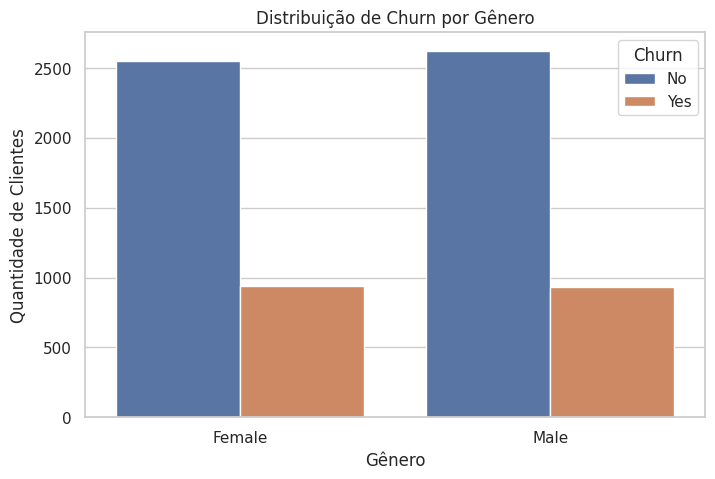

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='customer.gender',
    hue='Churn',
    data=df
)

plt.title('Distribuição de Churn por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Clientes')

plt.show()

**Total Gasto vs Churn**

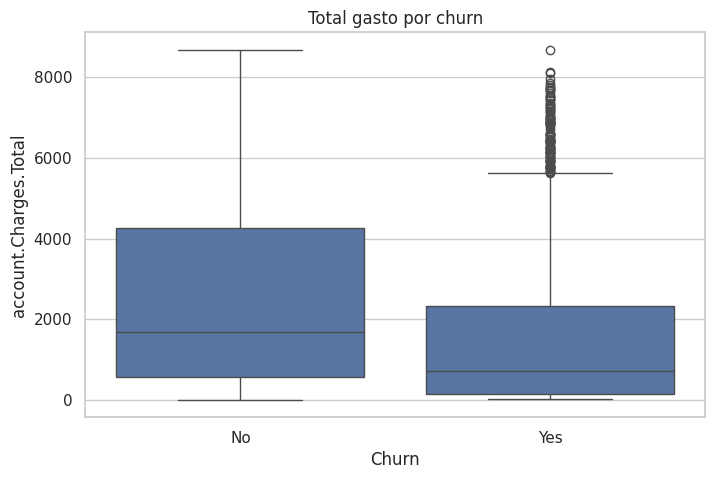

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='account.Charges.Total',
    data=df
)

plt.title('Total gasto por churn')

plt.show()

**Tempo de Contrato vs Churn**

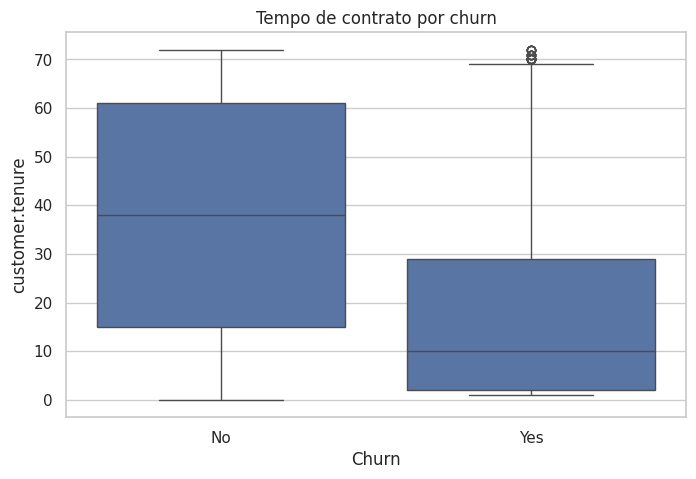

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='customer.tenure',
    data=df
)

plt.title('Tempo de contrato por churn')

plt.show()

# **Relatório Final — Análise de Evasão de Clientes (Churn)**
**1. Introdução**

A evasão de clientes (churn) representa um dos principais desafios para empresas que trabalham com serviços recorrentes, como empresas de telecomunicações. Identificar padrões associados ao cancelamento permite que as empresas desenvolvam estratégias de retenção mais eficazes.

Neste estudo foi realizada uma análise exploratória de dados com o objetivo de compreender os fatores associados à evasão de clientes da empresa Telecom X. A base utilizada contém informações demográficas, contratuais e financeiras dos clientes.

**2. Limpeza e tratamento dos dados**

Durante o processo de preparação dos dados foram realizadas as seguintes etapas:

* Importação da base a partir de uma API disponibilizada no GitHub

* Conversão da estrutura JSON em DataFrame utilizando pandas

* Identificação e tratamento de valores nulos ou vazios

* Padronização de variáveis categóricas

* Conversão de colunas numéricas para o tipo apropriado

* Remoção de registros duplicados

Também foi criada uma nova variável chamada Contas_Diarias, derivada do valor mensal pago pelo cliente.

**3. Análise exploratória de dados**

A análise exploratória buscou identificar padrões relacionados ao churn.

Foram analisados:

* distribuição geral de churn

* relação entre churn e variáveis categóricas (como gênero e tipo de contrato)

* comparação entre churn e variáveis numéricas (tempo de contrato e valor gasto)

Os gráficos indicam que clientes com menor tempo de contrato e menor valor total gasto apresentam maior probabilidade de cancelamento.

**4. Conclusões**

A análise sugere alguns padrões relevantes:

* clientes com menor tempo de contrato apresentam maior probabilidade de evasão

* clientes que gastam menos ao longo do relacionamento tendem a cancelar com maior frequência

* não foi observada diferença significativa entre gêneros em relação ao churn

**5. Recomendações**

Com base na análise, recomenda-se:

* desenvolver estratégias de retenção voltadas para clientes recentes

* criar programas de fidelidade que incentivem a permanência por mais tempo

* monitorar clientes com baixo nível de consumo e oferecer serviços adicionais ou planos mais adequados

Essas informações podem servir de base para o desenvolvimento de modelos preditivos de churn em etapas futuras do projeto.